### 2026-02-06 time-mean biases

AIMIP evaluations of time-mean biases in the train (1979-2014, in-sample) and test (2015-2024, out of sample) periods.

In [48]:
import xarray as xr
import numpy as np
import os
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    ERA5_1DEG,
    open_aimip_data,
    regrid_dataset,
    transfer_attrs,
)

In [2]:
def compute_time_mean(ds: xr.Dataset, start: str, end: str, time_dim_name: str='time') -> xr.Dataset:
    time_subset = ds.sel(**{time_dim_name: slice(start, end)})
    with xr.set_options(keep_attrs=True):
        return time_subset.mean(time_dim_name)

def compute_biases(pred_time_mean: xr.Dataset, target_time_mean: xr.Dataset) -> xr.Dataset:
    biases = pred_time_mean - target_time_mean
    biases = transfer_attrs(pred_time_mean, biases)
    return biases

def compute_rmsb(biases: xr.Dataset, lat_dim: str='lat', lon_dim: str='lon') -> xr.Dataset:
    weights = np.cos(np.deg2rad(biases[lat_dim]))
    rmsb = np.sqrt((biases ** 2).weighted(weights).mean(dim=[lat_dim, lon_dim]))
    rmsb = transfer_attrs(biases, rmsb)
    return rmsb

In [10]:
TRAINING_DATES = ('1979-10-01', '2014-12-31')
TEST_DATES = ('2015-01-01', '2024-12-31')
OUTDIR = './figures'

In [ ]:
monthly_data, missing_files = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)

In [5]:
missing_files

{'Ai2/ACE2-1-ERA5': ['../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_

In [6]:
era5_monthly_1deg, missing_files_era5 = open_aimip_data(
    [ERA5_1DEG],
    EVALUATION_VARIABLES,
    table='Amon',
    n_realizations=1,
)
era5_monthly_1deg = (
    era5_monthly_1deg['ERA5']
    .isel(realization=0).squeeze()
    .drop_vars(['forecast_period', 'originating_centre'])
    .sel(lat=slice(-85, 85))
)

ERA5
specific_humidity
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_hus_1978-2024.nc
surface_specific_humidity
Not found: ../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_huss_1978-2024.nc
dew_point_temperature
Not found: ../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tdas_1978-2024.nc
precipitation_flux
Not found: ../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_pr_1978-2024.nc
surface_air_pressure
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ps_1978-2024.nc
air_pressure_at_sea_level
Not found: ../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_psl_1978-2024.nc
air_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ta_1978-2024.nc
air_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tas_1978-2024.nc
surface_temperature
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ts_1978-2024.nc
eastward_wind
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ua_1978-2024.nc
eastward_wind
../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_

/home/brianhenn/dev/AIMIP/evaluations/aimip_data_utils.py:334: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/evaluations/aimip_data_utils.py:334: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' att

In [7]:
missing_files_era5

{'ERA5': ['../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_huss_1978-2024.nc',
  '../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tdas_1978-2024.nc',
  '../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_pr_1978-2024.nc',
  '../local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_psl_1978-2024.nc']}

In [8]:
list(monthly_data.keys())

['Ai2/ACE2-1-ERA5',
 'ArchesWeather/ArchesWeather-V2',
 'ArchesWeather/ArchesWeatherGen-V2',
 'Google/NeuralGCM',
 'Google/NeuralGCM-HRD',
 'NVIDIA/CMIP6/AIMIP/NVIDIA/cBottle-1-3',
 'UMD-PARETO/MD-1p5']

In [12]:
with xr.set_options(keep_attrs=True):
    time_mean = {
        k: xr.concat(
            [
                compute_time_mean(v, start=TRAINING_DATES[0], end=TRAINING_DATES[1]).expand_dims({'time_period': ['training']}),
                compute_time_mean(v, start=TEST_DATES[0], end=TEST_DATES[1]).expand_dims({'time_period': ['test']}),
            ],
            dim='time_period'
        ) for k, v in monthly_data.items()
    }

In [13]:
with ProgressBar():
    time_mean = {
        k: v.compute() for k, v in time_mean.items()
    }

[########################################] | 100% Completed | 130.62 s
[########################################] | 100% Completed | 99.12 s
[########################################] | 100% Completed | 100.37 s
[########################################] | 100% Completed | 62.98 s
[########################################] | 100% Completed | 87.38 s
[########################################] | 100% Completed | 196.03 s
[########################################] | 100% Completed | 218.00 s


In [14]:
with xr.set_options(keep_attrs=True):
    time_mean_era5 = xr.concat(
        [
            compute_time_mean(era5_monthly_1deg, start=TRAINING_DATES[0], end=TRAINING_DATES[1]).expand_dims({'time_period': ['training']}),
            compute_time_mean(era5_monthly_1deg, start=TEST_DATES[0], end=TEST_DATES[1]).expand_dims({'time_period': ['test']}),
        ],
        dim='time_period'
    )

In [15]:
with ProgressBar():
    time_mean_era5 = time_mean_era5.compute()

[########################################] | 100% Completed | 73.02 s


In [53]:
regridded_time_means = []
for experiment_submission_name, dataset in time_mean.items():
    print(experiment_submission_name)
    if experiment_submission_name != 'NVIDIA/CMIP6/AIMIP/NVIDIA/cBottle-1-3':
        regridder_kwargs = dict(method='conservative')
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    target_grid = time_mean_era5.isel(time_period=0)[['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    regridded_time_mean = regrid_dataset(
        dataset,
        target_grid,
        sample_dims=['realization', 'time_period'],
        **regridder_kwargs
    )
    regridded_time_means.append(
        regridded_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_time_means = xr.concat(regridded_time_means, dim='experiment_submission', join='outer', combine_attrs='override')

Ai2/ACE2-1-ERA5
ArchesWeather/ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeather/ArchesWeatherGen-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


Google/NeuralGCM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

Google/NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

NVIDIA/CMIP6/AIMIP/NVIDIA/cBottle-1-3
UMD-PARETO/MD-1p5


In [55]:
# ArchesWeather surface temperature has wrong units (C); also is not defined over land
regridded_time_means.ts.loc[
    {'experiment_submission': slice('ArchesWeather/ArchesWeather-V2', 'ArchesWeather/ArchesWeatherGen-V2')}
] = regridded_time_means.ts.sel(experiment_submission = ['ArchesWeather/ArchesWeather-V2', 'ArchesWeather/ArchesWeatherGen-V2']) + 273.15

In [56]:
biases = compute_biases(regridded_time_means, time_mean_era5)
rmsb = compute_rmsb(biases)

/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xarray/plot/facetgrid.py:685: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self.fig.tight_layout()


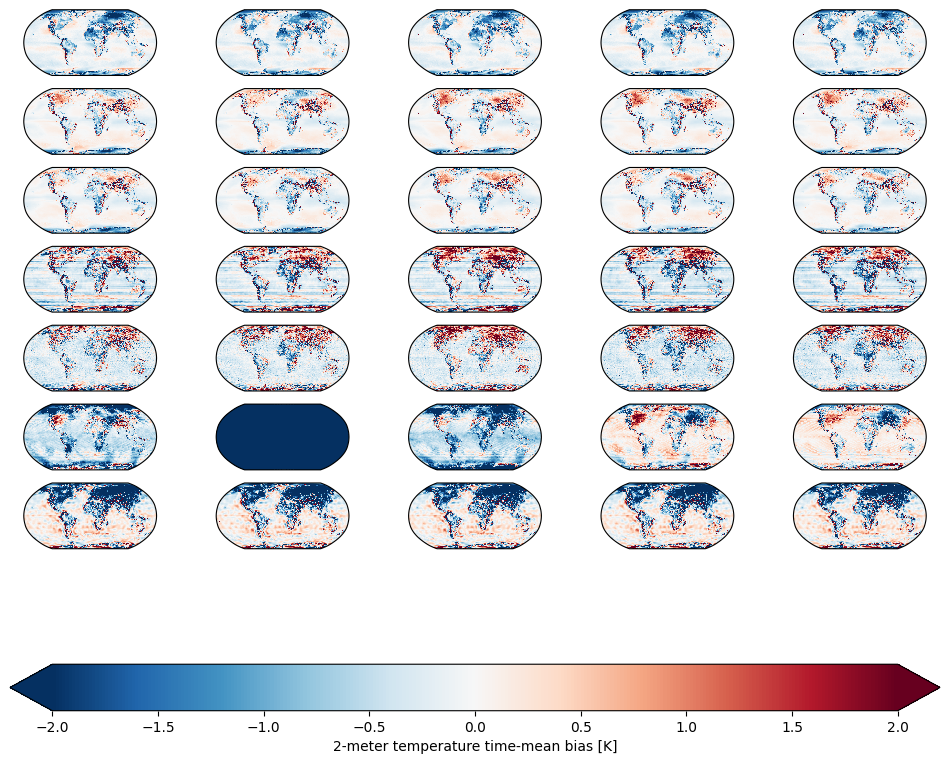

In [59]:
fg = biases.sel(time_period='test').tas.plot(
    row='experiment_submission', col='realization', cmap='RdBu_r', vmin=-2, vmax=2,
    subplot_kws=dict(projection=ccrs.Robinson()),
    transform=ccrs.PlateCarree(),
    figsize=(12, 10),
    cbar_kwargs=dict(label='2-meter temperature time-mean bias [K]', orientation='horizontal')
)
fg.set_titles('')
fg.fig.patch.set_alpha(0.0)
fg.fig.savefig(os.path.join(OUTDIR, 'bias_test_2m_temp.png'), bbox_inches='tight')

/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xarray/plot/facetgrid.py:685: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self.fig.tight_layout()


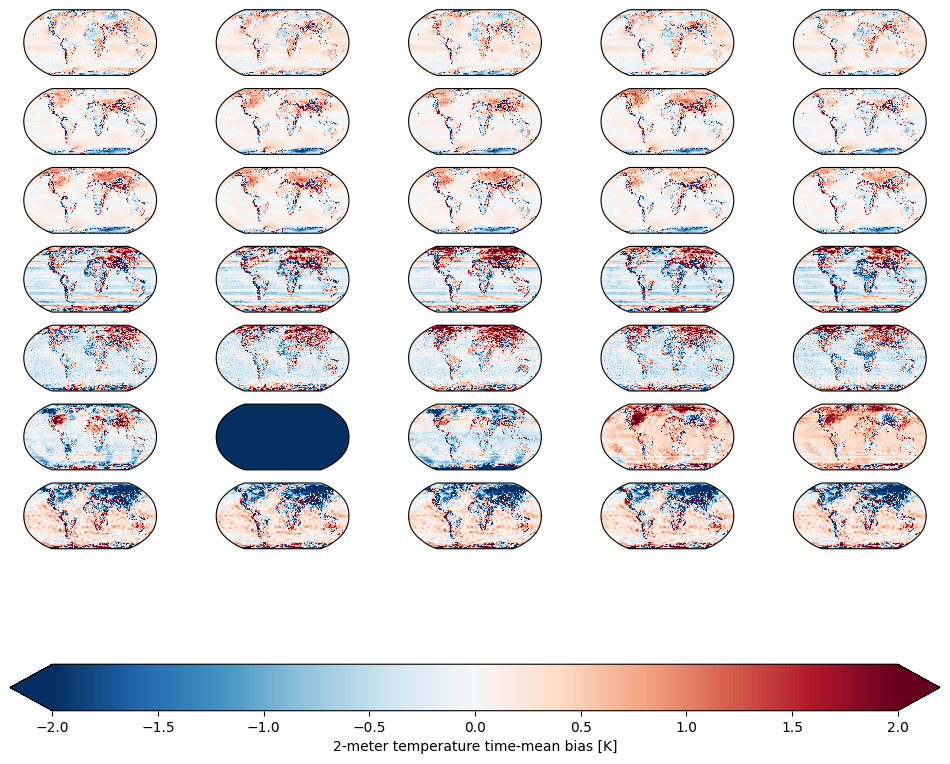

In [60]:
fg = biases.sel(time_period='training').tas.plot(
    row='experiment_submission', col='realization', cmap='RdBu_r', vmin=-2, vmax=2,
    subplot_kws=dict(projection=ccrs.Robinson()),
    transform=ccrs.PlateCarree(),
    figsize=(12, 10),
    cbar_kwargs=dict(label='2-meter temperature time-mean bias [K]', orientation='horizontal')
)
fg.set_titles('')
fg.fig.patch.set_alpha(0.0)
fg.fig.savefig(os.path.join(OUTDIR, 'bias_training_2m_temp.png'), bbox_inches='tight')

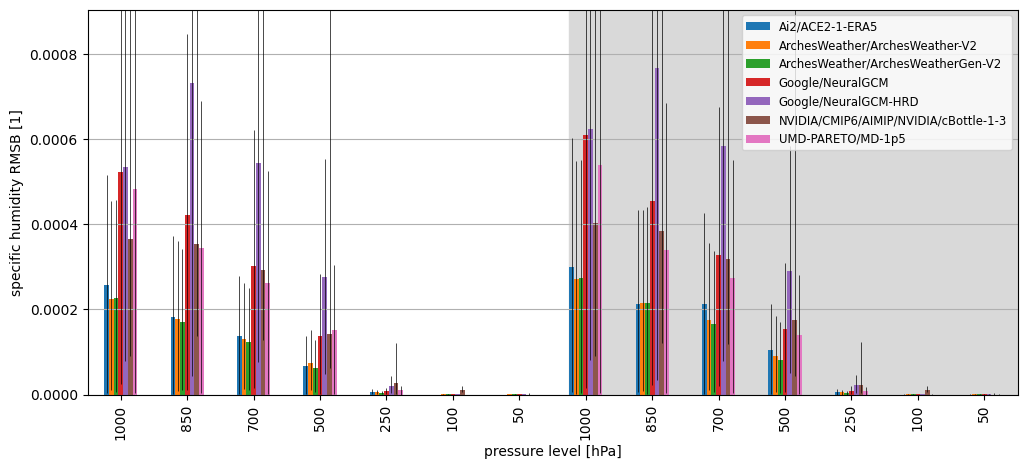

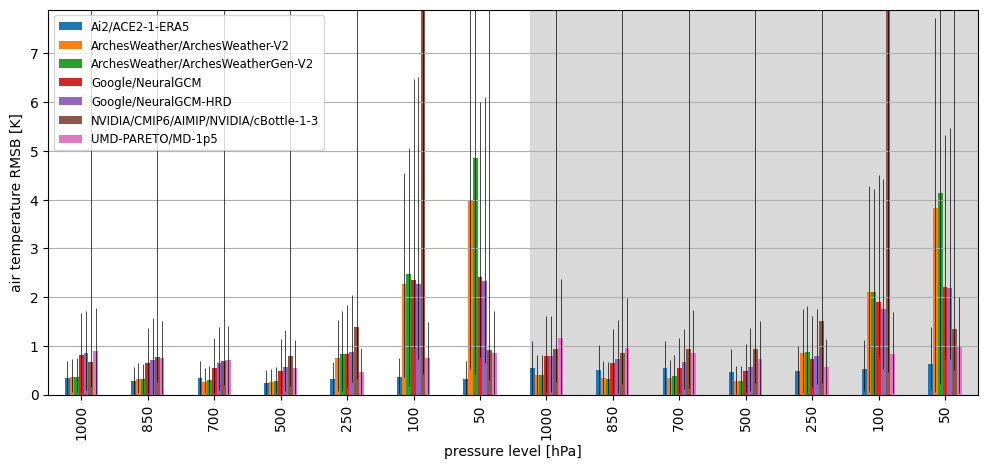

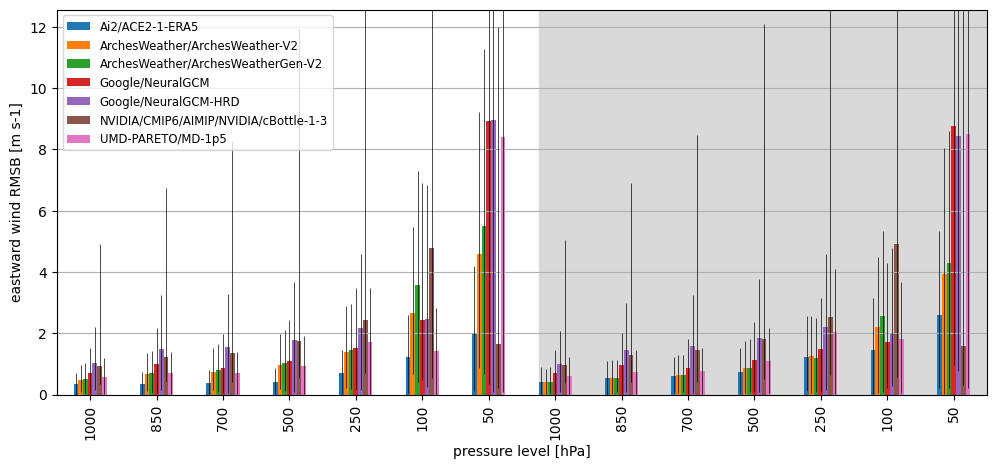

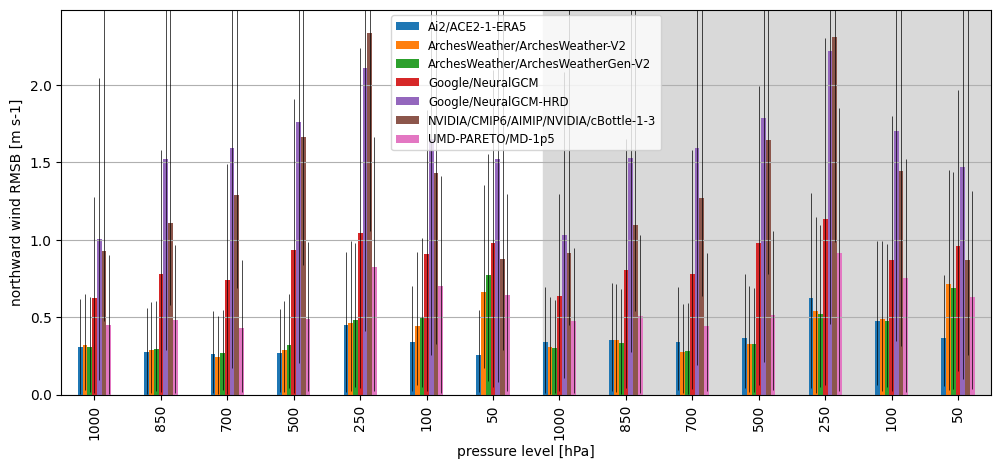

In [61]:
for varname in [varname for varname in rmsb.data_vars if "plev" in rmsb[varname].dims]:
    fig, ax = plt.subplots(figsize=(12, 5))
    stats = rmsb[varname].rename('RMSB').transpose('time_period', 'plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        stats.min('realization').to_dataframe().unstack(),
        stats.median('realization').to_dataframe().unstack(),
        stats.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax,
        legend=False,
        yerr=np.concat([lowest.values.T[:, None, :], highest.values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(rmsb.experiment_submission.values, fontsize='small')
    ymax = median.max().mean() * 2
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([xlim[1] / 2, xlim[1]], [0, 0], [ylim[1], ylim[1]], color=[0.85, 0.85, 0.85], zorder=-1)
    ax.set_xticklabels([str(round(ind[1]/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{rmsb[varname].attrs.get('long_name', varname)} RMSB [{rmsb[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"RMSB_{varname}.png"), bbox_inches='tight')

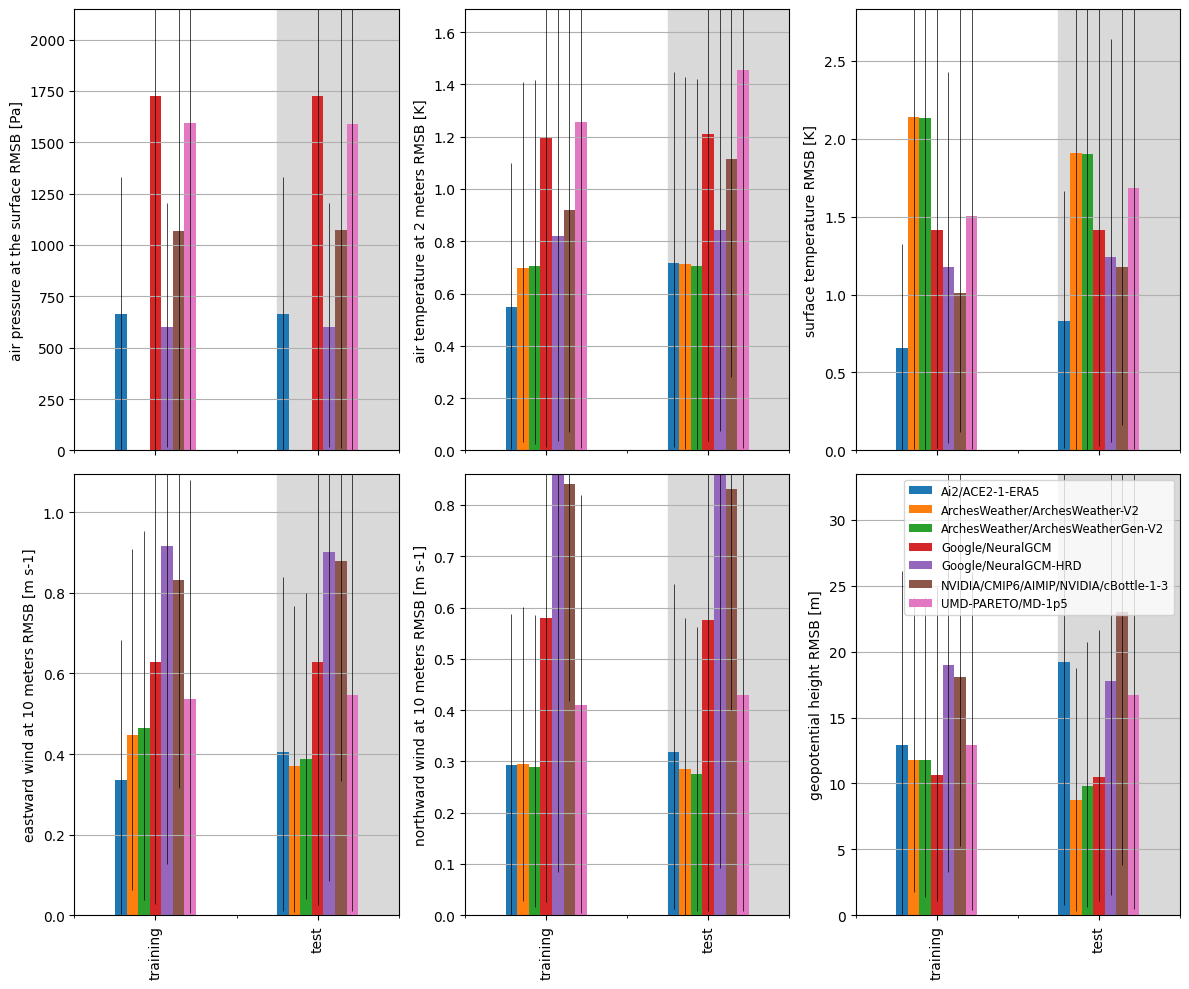

In [62]:
surface_vars = [var for var in rmsb.data_vars if "plev" not in rmsb[var].coords]
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(12, 10), sharex=True, sharey=False)
for ax, varname in zip(axes.flatten(), surface_vars):
    stats = rmsb[varname].transpose('time_period', 'experiment_submission', 'realization')
    lowest, median, highest = (
        stats.min('realization').to_dataframe().unstack(),
        stats.median('realization').to_dataframe().unstack(),
        stats.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax,
        legend=False,
        yerr=np.concat([lowest.values.T[:, None, :], highest.values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-1]:
        ax.legend(rmsb.experiment_submission.values, fontsize='small')
    ymax = median.max().median() * 2
    ax.set_ylim([0, ymax])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.fill_between([xlim[1] / 2, xlim[1]], [0, 0], [ylim[1], ylim[1]], color=[0.85, 0.85, 0.85], zorder=-1)
    ax.set_xticklabels([ind for ind in median.index])
    ax.set_xlabel('')
    ax.set_ylabel(f"{rmsb[varname].attrs.get('long_name', varname)} RMSB [{rmsb[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.tight_layout()
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, "RMSB_surface_variables.png"), bbox_inches='tight')